# Homework 2

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset

In [60]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [61]:
!wget $data

--2026-10-05 00:39:09--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolvendo raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8002::154, 2606:50c0:8000::154, ...
Conectando-se a raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8003::154|:443... conectado.
A requisição HTTP foi enviada, aguardando resposta... 200 OK
Tamanho: 635180 (620K) [text/plain]
Salvando em: ‘car_fuel_efficiency_2026.csv.2’

car_fuel_efficiency 100%[===================>] 620,29K  2,59MB/s    em 0,2s    

2026-10-05 00:39:10 (2,59 MB/s) - ‘car_fuel_efficiency_2026.csv.2’ salvo [635180/635180]



In [5]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [6]:
df.columns 

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='object')

In [8]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

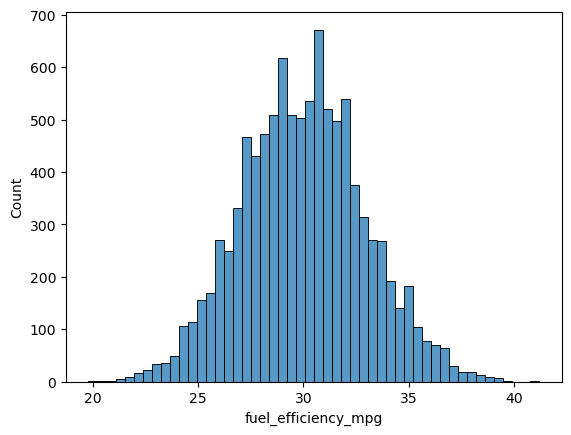

In [11]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

### fuel_efficiency_mpg does not have a long tail.

## Question 1

### There's one column with missing values. What is it?

In [12]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Question 2

### What's the median (50% percentile) for variable 'horsepower'?

In [13]:
df.horsepower.median()

254.0

### Prepare and split the dataset

### Shuffle the filtered dataset and create the split exactly as in the lecture:

In [15]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

## Question 3

- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
- Which option gives better RMSE?

In [19]:
# y values:

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [33]:
# Functions definitions:

def prepare(df, base, fill_with):
    X = df[base].fillna(fill_with).values
    return X

def train_linear_regression(X, Y):

    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    Gram_Matrix = X.T.dot(X)
    Gram_Matrix_inv = np.linalg.inv(Gram_Matrix)
    W = Gram_Matrix_inv.dot(X.T).dot(Y)

    return W

def rmse(y, y_pred):
    error = y_pred - y
    squared_error = error ** 2
    mean_squared_error = squared_error.mean()
    return np.sqrt(mean_squared_error)


def linear_regression(X, W):
    return W[0] + X.dot(W[1: ])

In [34]:
# Fill 0:

base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

# Train:  
X_train = prepare(df_train, base, 0)
W = train_linear_regression(X_train, y_train)

# Validation:
X_val = prepare(df_val, base, 0)
y_pred = linear_regression (X_val, W)

# Testing:
print(rmse(y_val, y_pred).round(3))

2.205


In [36]:
# Fill with mean of horsepower:

mean = df_train.horsepower.mean()
# print(mean)

base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

# Train:  
X_train = prepare(df_train, base, mean)
W = train_linear_regression(X_train, y_train)

# Validation:
X_val = prepare(df_val, base, mean)
y_pred = linear_regression (X_val, W)

# Testing:
print(rmse(y_val, y_pred).round(3))

2.202


## Question 4

- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
- Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.
- Which r gives the best RMSE?

If multiple options give the same best RMSE, select the smallest r.

In [39]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

print(f"{'r':>6} | {'w0':>12} | {'rmse':>8}")
print('-' * 32)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare(df_train, base, 0)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare(df_val, base, 0)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(f"{r:>6} | {w0:>12.4f} | {score:>8.4f}")



     r |           w0 |     rmse
--------------------------------
     0 |    -153.8850 |   2.2053
  0.01 |    -148.3092 |   2.2058
   0.1 |    -111.8387 |   2.2241
     1 |     -32.3319 |   2.3492
     5 |      -7.7729 |   2.4094
    10 |      -3.9871 |   2.4195
   100 |      -0.4082 |   2.4292


### Question 5

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with a 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits using `round(std, 3)`.


In [62]:
score = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

    # Train:  
    X_train = prepare(df_train, base, 0)
    W = train_linear_regression(X_train, y_train)

    # Validation:
    X_val = prepare(df_val, base, 0)
    y_pred = linear_regression (X_val, W)

    # rmse:
    score.append(rmse(y_val, y_pred))
    print(f'seed = {seed}: rmse = {rmse(y_val, y_pred).round(3)}') 

print()
print(f'mean = {np.mean(score).round(4)}\nstd = {np.std(score).round(3)}')

seed = 0: rmse = 2.239
seed = 1: rmse = 2.202
seed = 2: rmse = 2.163
seed = 3: rmse = 2.204
seed = 4: rmse = 2.202
seed = 5: rmse = 2.246
seed = 6: rmse = 2.27
seed = 7: rmse = 2.191
seed = 8: rmse = 2.217
seed = 9: rmse = 2.207

mean = 2.2141
std = 0.029


## Question 6

- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.
- What's the RMSE on the test dataset?


In [59]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

y_train = df_train.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

# Train:  
X_train = prepare(df_train, base, 0)

w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)

X_test = prepare(df_test, base, 0)
y_pred = w0 + X_test.dot(w)

# Testing:
X_val = prepare(df_test, base, 0)
y_pred = linear_regression (X_val, W)

# rmse:
print(f'seed = {9}: rmse = {rmse(y_test, y_pred).round(3)}') 


seed = 9: rmse = 2.236
